# Customer Churn Prediction using Logistic Regression
## AI-ML Assignment - 2

---


## Task 1: Data Understanding

**Goal**: Load the Telco Customer Churn dataset, inspect its structure, view the first five records, and identify numerical features, categorical features, and the target variable.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Dataset loaded successfully. Shape: {df.shape}")


Dataset loaded successfully. Shape: (7043, 21)


In [2]:
# Display the first five records
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Display column names, non-null counts, and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Feature Identification

Based on the dataset structure:
1. **Numerical Features**:
   - `tenure`: Number of months the customer has stayed with the company.
   - `MonthlyCharges`: The amount charged to the customer monthly.
   - `TotalCharges`: The total amount charged to the customer (needs to be converted to numeric).

2. **Categorical Features**:
   - **Demographics**: `gender` (Female/Male), `SeniorCitizen` (0/1), `Partner` (Yes/No), `Dependents` (Yes/No).
   - **Services**: `PhoneService` (Yes/No), `MultipleLines` (Yes/No/No phone service), `InternetService` (DSL/Fiber optic/No), `OnlineSecurity` (Yes/No/No internet service), `OnlineBackup` (Yes/No/No internet service), `DeviceProtection` (Yes/No/No internet service), `TechSupport` (Yes/No/No internet service), `StreamingTV` (Yes/No/No internet service), `StreamingMovies` (Yes/No/No internet service).
   - **Account/Contract Info**: `Contract` (Month-to-month/One year/Two year), `PaperlessBilling` (Yes/No), `PaymentMethod` (Electronic check/Mailed check/Bank transfer/Credit card).
   - **Note**: `customerID` is a unique identifier and is not a predictive feature, so it will be removed during preprocessing.

3. **Target Variable**:
   - `Churn`: Indicates whether the customer left within the last month (Yes/No).


## Task 2: Data Preprocessing

**Goal**: Inspect and handle missing values, encode categorical variables, scale numerical features, and split the dataset into 80% training and 20% testing sets.


In [4]:
# Check for standard missing values (NaN)
print("Standard missing values per column:")
print(df.isnull().sum())

# Check for empty spaces in the TotalCharges column
empty_spaces = (df['TotalCharges'].str.strip() == '').sum()
print(f"\nNumber of empty spaces in 'TotalCharges': {empty_spaces}")


Standard missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Number of empty spaces in 'TotalCharges': 11


In [5]:
# Convert TotalCharges to numeric, setting empty spaces to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Print records where TotalCharges is NaN
nan_records = df[df['TotalCharges'].isnull()]
print("Records with NaN TotalCharges (showing tenure and MonthlyCharges):")
print(nan_records[['tenure', 'MonthlyCharges', 'TotalCharges']])

# Since tenure is 0 for these customers, they have not completed their first billing cycle.
# We will impute their TotalCharges with 0.0
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# Verify that there are no remaining missing values
print(f"\nRemaining missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")


Records with NaN TotalCharges (showing tenure and MonthlyCharges):
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN

Remaining missing values in TotalCharges: 0


In [6]:
# Drop customerID as it is a unique identifier, not a predictor
df_prep = df.drop(columns=['customerID'])

# Convert Churn target variable to binary (1 for Yes, 0 for No)
df_prep['Churn'] = df_prep['Churn'].map({'Yes': 1, 'No': 0})

# Identify numerical and categorical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [col for col in df_prep.columns if col not in num_cols + ['Churn']]

# Apply One-Hot Encoding to categorical features (using drop_first=True to avoid dummy variable trap)
df_encoded = pd.get_dummies(df_prep, columns=cat_cols, drop_first=True)

# Display shape and columns of encoded dataframe
print(f"Encoded dataframe shape: {df_encoded.shape}")
df_encoded.head()


Encoded dataframe shape: (7043, 31)


,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,0,False,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,34,56.95,1889.50,0,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,45,42.30,1840.75,0,True,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,2,70.70,151.65,1,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [7]:
# Separate features (X) and target (y)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Split the dataset into 80% training and 20% testing
# We use stratify=y to maintain target class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}, Target: {y_train.shape}")
print(f"Testing features shape: {X_test.shape}, Target: {y_test.shape}")


Training features shape: (5634, 30), Target: (5634,)
Testing features shape: (1409, 30), Target: (1409,)


In [8]:
# Scaling numerical features is essential for Logistic Regression to converge 
# and to allow correct coefficient comparison.
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("First 3 rows of scaled training features (showing tenure, MonthlyCharges, TotalCharges):")
X_train_scaled[num_cols].head(3)


First 3 rows of scaled training features (showing tenure, MonthlyCharges, TotalCharges):


,tenure,MonthlyCharges,TotalCharges
3738,0.102371,-0.521976,-0.262257
3151,-0.711743,0.337478,-0.503635
4860,-0.793155,-0.809013,-0.749883


## Task 3: Model Development

**Goal**: Build a Logistic Regression model using the scaled and preprocessed features, train it on the training set, and predict customer churn on the test dataset.


In [9]:
# Instantiate and train the Logistic Regression model
# Increased max_iter to ensure convergence
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Predict binary churn labels on the test dataset
y_pred = model.predict(X_test_scaled)

# Predict probabilities on the test dataset (for inspection / threshold tuning if needed)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Model training complete. Churn predictions generated on test set.")


Model training complete. Churn predictions generated on test set.


## Task 4: Model Evaluation

**Goal**: Evaluate the performance of our model using Accuracy, Precision, Recall, and F1-Score. Generate a Confusion Matrix and formulate key observations.


In [10]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("--- Model Performance Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


--- Model Performance Metrics ---
Accuracy:  0.8062
Precision: 0.6593
Recall:    0.5588
F1-Score:  0.6049

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



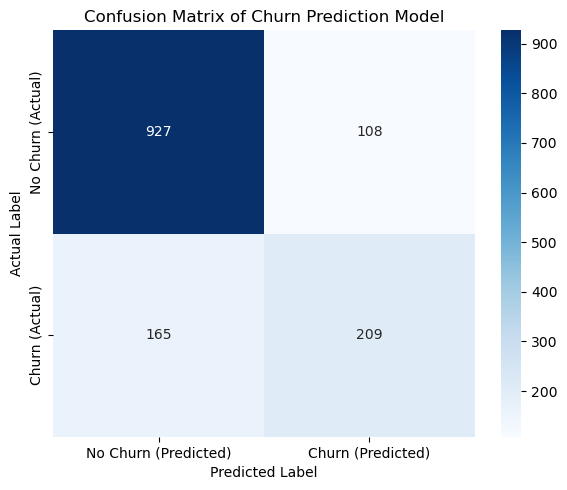

In [11]:
# Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn (Predicted)', 'Churn (Predicted)'], 
            yticklabels=['No Churn (Actual)', 'Churn (Actual)'])
plt.title('Confusion Matrix of Churn Prediction Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


In [12]:
# Analyze coefficients to extract model observations
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Top 5 factors increasing Churn probability:")
print(coefficients.head(5).to_string(index=False))

print("\nTop 5 factors decreasing Churn probability:")
print(coefficients.tail(5).to_string(index=False))


Top 5 factors increasing Churn probability:
                       Feature  Coefficient
   InternetService_Fiber optic     1.180666
                  TotalCharges     0.527772
PaymentMethod_Electronic check     0.392775
               StreamingTV_Yes     0.374831
          PaperlessBilling_Yes     0.374218

Top 5 factors decreasing Churn probability:
          Feature  Coefficient
   MonthlyCharges    -0.466504
 PhoneService_Yes    -0.520750
Contract_One year    -0.683857
           tenure    -1.257131
Contract_Two year    -1.313803


### Task 4: Observations

1. **Overall Performance & Class Imbalance**:
   The model achieves a solid overall accuracy of **80.62%**. However, because the dataset contains a significantly larger number of non-churned customers (1035 in test set) than churned customers (374 in test set), there is a class imbalance. This causes the model to have a higher precision (**65.93%**) but a lower recall (**55.88%**). The F1-Score of **60.49%** highlights that there is a trade-off, and the model misses about 44% of customers who actually churn.

2. **Key Positive Drivers of Churn**:
   Subscribing to **Fiber optic internet** (`InternetService_Fiber optic` coefficient: `+1.18`) is the strongest positive driver, indicating that fiber optic subscribers are highly likely to churn. This might point to billing issues, pricing, or connection quality complaints. Other positive indicators include paying via **Electronic Check** (`+0.39`), having **Paperless Billing** (`+0.37`), and subscribing to **Streaming TV** (`+0.37`).

3. **Key Negative Drivers of Churn (Retention Factors)**:
   Longer customer **tenure** (`tenure` coefficient: `-1.26`) and having a **Two-year contract** (`Contract_Two year` coefficient: `-1.31`) are the strongest negative drivers. This shows that long-term loyalty and contract lengths are the most effective buffers against churn. Having a **One-year contract** (`-0.68`) and subscribing to **Phone Service** (`-0.52`) are also strong retention indicators.


## Task 5: Conclusion

**Goal**: Present a brief synthesis of the findings, key factors, and a limitation of Logistic Regression for this task.

### Synthesis of Results
This study built a Logistic Regression model to predict customer churn with 80.6% accuracy. Key findings indicate that longer customer tenure and two-year contracts strongly decrease churn probability, acting as key retention factors. Conversely, subscribing to Fiber Optic internet and paying via Electronic Check significantly increase churn likelihood, highlighting potential service dissatisfaction or billing friction. A major limitation of Logistic Regression in this scenario is its assumption of linearity between independent features and log-odds of the target. It cannot capture complex, non-linear relationships or multi-feature interactions (e.g., tenure combined with specific contract and support tickets) without manual, complex feature engineering, unlike non-linear algorithms such as Random Forests or Gradient Boosting Machines.
